In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from datetime import datetime, timedelta

LOG_FILE = "runs/gruyere-2.0/r1/gruyere_2_0/train.log"

train_rows, val_rows = [], []

with open(LOG_FILE, "r") as f:
    for line in f:
        parts = line.split()
        if len(parts) < 2 or not parts[0].isdigit():
            continue

        step = int(parts[0])
        kind = parts[1]

        values = {
            k: float(v)
            for k, v in re.findall(r"(\w+)=([\d.eE+-]+)", line)
        }

        if kind == "train":
            train_rows.append({"step": step, **values})
        elif kind == "val":
            val_rows.append({"step": step, **values})

train = pd.DataFrame(train_rows)
val = pd.DataFrame(val_rows)

if len(train):
    min_idx = train["loss"].idxmin()
    min_loss = train.loc[min_idx, "loss"]
    min_step = int(train.loc[min_idx, "step"])

    total_time = train["dt"].sum()
    avg_tok_sec = train["tok_sec"].mean()
    total_tokens = train["tokens"].iloc[-1]

    print(f"Steps:             {len(train):,}")
    print(f"Epoch:             {train['epoch'].iloc[-1]:.4f}")
    print(f"Tokens:            {total_tokens / 1e9:.3f}B")
    print(f"Total step time:   {total_time / 3600:.2f} hours")
    print(f"Average tok/sec:   {avg_tok_sec:,.0f}")
    print(f"Lowest train loss: {min_loss:.6f} at step {min_step:,}")

if len(val):
    min_idx = val["loss"].idxmin()
    print(
        f"Lowest val loss:   {val.loc[min_idx, 'loss']:.6f} "
        f"at step {int(val.loc[min_idx, 'step']):,}"
    )

TARGET_TOKENS = 8.17e9
recent_toks_sec = train["tok_sec"].tail(500).mean()
print(f"Recent tok/sec:    {avg_tok_sec:,.0f}")
remaining_tok = max(0, TARGET_TOKENS - total_tokens)
remaining_sec = remaining_tok / recent_toks_sec
finish_time = datetime.now() + timedelta(seconds=remaining_sec)
progress = total_tokens / TARGET_TOKENS * 100

print(f"Progress:          {progress:.2f}% ({total_tokens / 1e9:.3f}B / {TARGET_TOKENS / 1e9:.2f}B)")
print(f"Tokens Remaining:  {remaining_tok / 1e9:.3f}B")
print(f"Time Remaining:    {remaining_sec / 3600:.2f} hours")
print(f"Estimated Finish:  {finish_time.strftime('%d %b %Y, %H:%M')}")

Steps:             17,142
Epoch:             0.8800
Tokens:            8.987B
Total step time:   16.50 hours
Average tok/sec:   151,523
Lowest train loss: 2.822574 at step 17,117
Lowest val loss:   2.967294 at step 17,000
Recent tok/sec:    151,523
Progress:          110.00% (8.987B / 8.17B)
Tokens Remaining:  0.000B
Time Remaining:    0.00 hours
Estimated Finish:  02 Oct 2026, 09:07


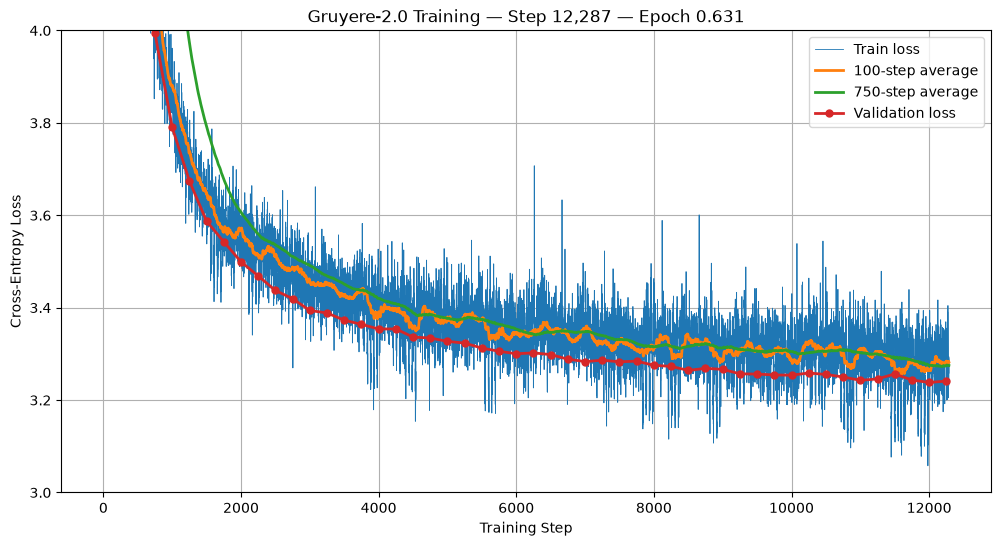

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    train["step"],
    train["loss"],
    linewidth=0.6,
    #alpha=0.25,
    label="Train loss",
)

for window in [100, 750]:
    if len(train) >= window:
        smooth = train["loss"].rolling(window, min_periods=1).mean()
        ax.plot(
            train["step"],
            smooth,
            linewidth=2,
            label=f"{window}-step average",
        )

if len(val):
    ax.plot(
        val["step"],
        val["loss"],
        marker="o",
        markersize=5,
        linewidth=2,
        label="Validation loss",
    )

ax.set_xlabel("Training Step")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title(
    f"Gruyere-2.0 Training — Step {int(train['step'].iloc[-1]):,} "
    f"— Epoch {train['epoch'].iloc[-1]:.3f}"
)
ax.grid(True, alpha=1)
ax.set_ylim(bottom=3, top=4)
ax.legend()
plt.show()

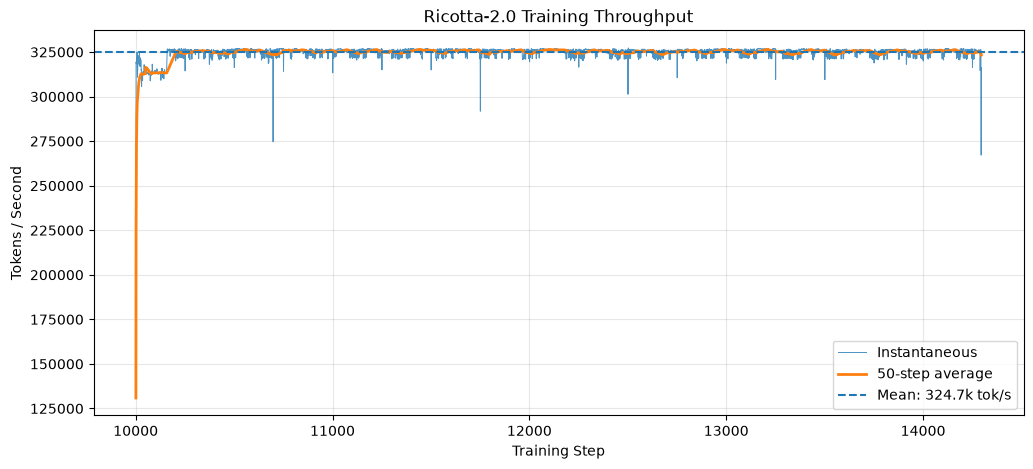

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["tok_sec"],
    linewidth=0.7,
    alpha=0.8,
    label="Instantaneous",
)

smooth = train["tok_sec"].rolling(50, min_periods=1).mean()

ax.plot(
    train["step"],
    smooth,
    linewidth=2,
    label="50-step average",
)

ax.axhline(
    train["tok_sec"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {train['tok_sec'].mean() / 1000:.1f}k tok/s",
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Tokens / Second")
ax.set_title("Ricotta-2.0 Training Throughput")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

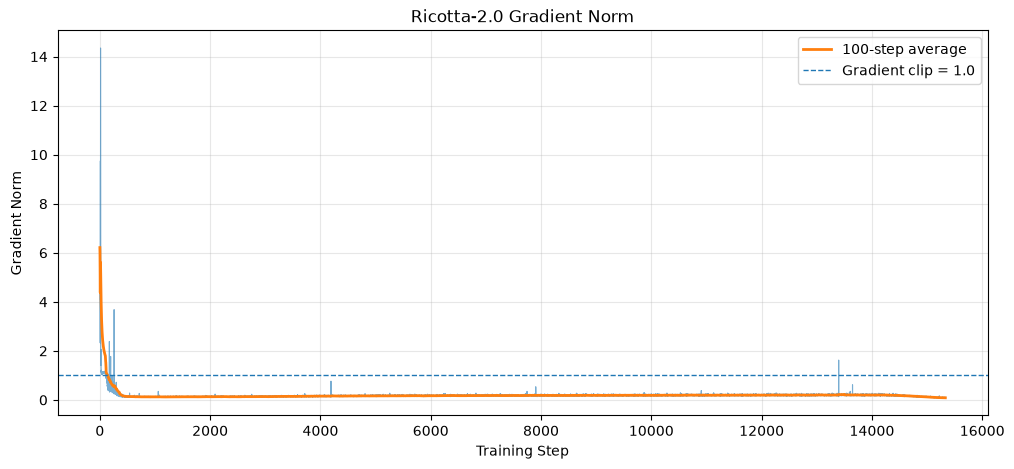

In [139]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["norm"],
    linewidth=0.8,
    alpha=0.6,
)

smooth = train["norm"].rolling(100, min_periods=1).mean()

ax.plot(
    train["step"],
    smooth,
    linewidth=2,
    label="100-step average",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Gradient clip = 1.0",
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Gradient Norm")
ax.set_title("Ricotta-2.0 Gradient Norm")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

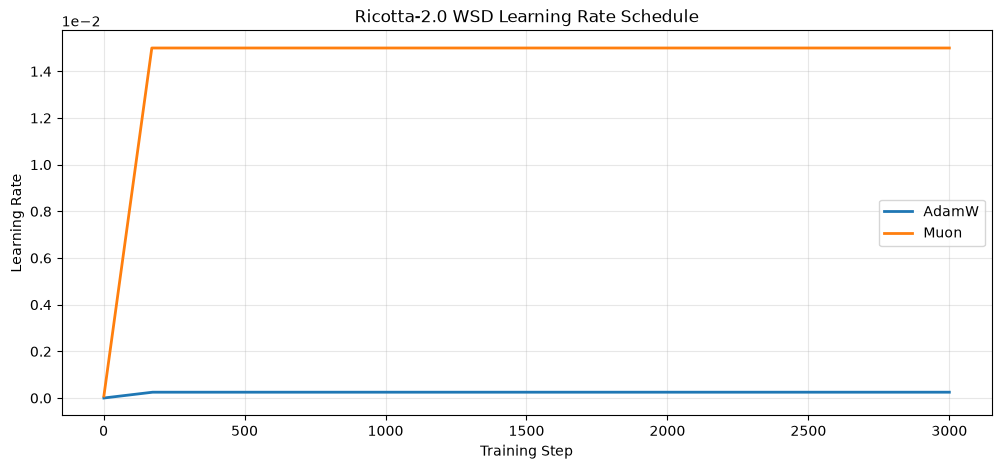

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["lr"],
    linewidth=2,
    label="AdamW",
)

ax.plot(
    train["step"],
    train["muon_lr"],
    linewidth=2,
    label="Muon",
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Ricotta-2.0 WSD Learning Rate Schedule")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

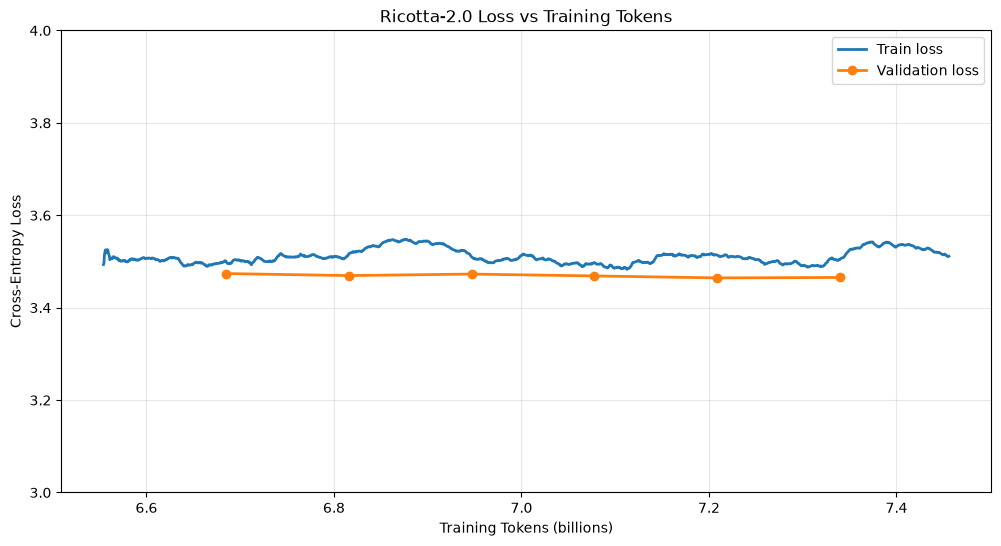

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

smooth = train["loss"].rolling(100, min_periods=1).mean()

ax.plot(
    train["tokens"] / 1e9,
    smooth,
    linewidth=2,
    label="Train loss",
)

if len(val):
    ax.plot(
        val["tokens"] / 1e9,
        val["loss"],
        marker="o",
        linewidth=2,
        label="Validation loss",
    )

ax.set_xlabel("Training Tokens (billions)")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Ricotta-2.0 Loss vs Training Tokens")
ax.set_ylim(top=4, bottom=3)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

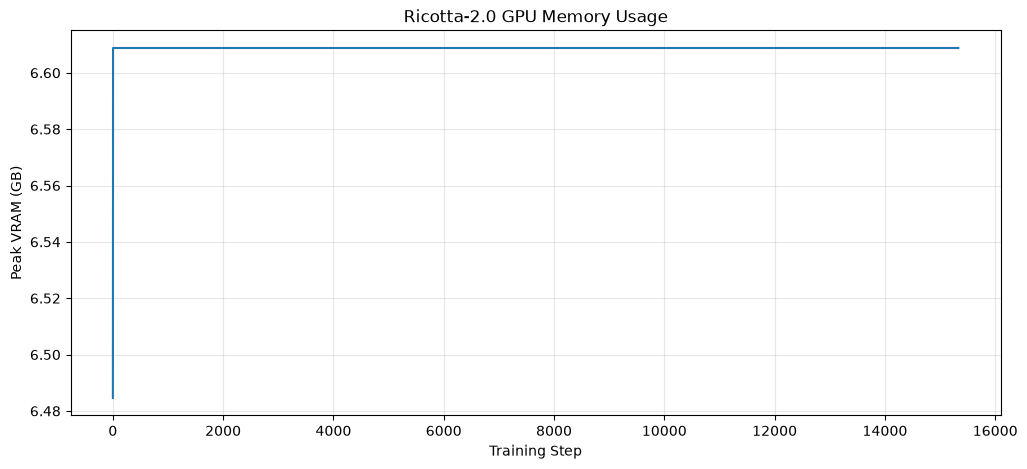

In [144]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["vram_gb"],
    linewidth=1.5,
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Peak VRAM (GB)")
ax.set_title("Ricotta-2.0 GPU Memory Usage")
ax.grid(True, alpha=0.3)
plt.show()